# HASH Health QA — fine-tune a generator for the Ghana configs (Colab GPU)

Retrieval is hard-capped on Aka_Gha / Eng_Gha (answers ~99% unique, oracle@20 ≈ 0.34–0.39),
so we fine-tune **mT5-small** (Apache-2.0) to generate bespoke answers, score them with our
exact local metric, and export Val + Test predictions to merge at home.

**Run every cell top-to-bottom.** You upload ONLY the 3 CSVs — the training script is written
by the `%%writefile` cell (cell 3), so there is no wrong-file-upload risk.

**Target to beat (Val mean-ROUGE):** Aka_Gha ≈ 0.356, Eng_Gha ≈ 0.332. Generation is merged
at home only if it beats these per subset (`make_submission_v5.py`).

In [ ]:
# 1. Confirm a GPU is attached (Runtime > Change runtime type > T4 GPU)
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [ ]:
# 2. Deps: Colab's defaults train fine; we just add rouge-score and remove the torchao that
#    breaks peft LoRA. (rouge-score is NOT preinstalled on Colab.)
!pip install -q rouge-score sentencepiece
!pip uninstall -q -y torchao
import transformers, peft, torch
print('transformers', transformers.__version__, '| peft', peft.__version__, '| cuda', torch.cuda.is_available())
import rouge_score; print('rouge_score OK')

transformers 5.10.2 | peft 0.19.1 | cuda True
rouge_score OK


In [ ]:
%%writefile train_generator.py
"""
train_generator.py — fine-tune an open seq2seq model (mT5 / AfriTeVa) on the weak
Ghana configs (Aka_Gha, Eng_Gha) where retrieval is hard-capped (~99% unique answers).

Rubric-grade fine-tuning:
  - train + validation split with per-epoch eval loss  -> LEARNING CURVES (history.csv)
  - optional LoRA / PEFT  (--use-lora)                  -> PEFT experiment
  - swap model with --model-name                        -> model-selection experiment
  - decoding controls (--beams, --gen-len)              -> inference-settings experiment
  - seeded, checkpointed, version-robust                -> reproducibility

Self-contained (no project imports) so it runs standalone on Colab GPU. Open-licensed deps:
transformers, datasets, accelerate, sentencepiece, rouge-score, peft (Apache/MIT).

Outputs (in --output-dir/<run-name>):
  history.csv   : step/epoch train_loss & eval_loss  (for learning-curve plots)
  val_gen.csv   : ID, subset, input, reference, gen_pred   (for local Val-gating)
  test_gen.csv  : ID, subset, input, gen_pred              (to merge into submission)
  metrics.json  : per-subset generation mean-ROUGE vs the retrieval baseline + config
  model/        : saved model (full) or LoRA adapter

Usage (Colab):
  python train_generator.py --data-dir data --output-dir out --run-name mt5_full \
      --model-name google/mt5-base --subsets Aka_Gha,Eng_Gha --epochs 4
  python train_generator.py ... --run-name mt5_lora --use-lora     # PEFT variant
"""
from __future__ import annotations
import argparse, inspect, json, os, random
import numpy as np
import pandas as pd

# retrieval baseline to beat (our rerank+hybrid, Val mean-ROUGE), for the verdict print
RETRIEVAL_BASELINE = {"Aka_Gha": 0.356, "Eng_Gha": 0.332, "Amh_Eth": 0.031}


def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    import torch
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def mean_rouge(refs, preds):
    """Our local metric: (ROUGE-1 F1 + ROUGE-L F1) / 2."""
    from rouge_score import rouge_scorer
    sc = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=False)
    r1 = rl = 0.0
    for r, p in zip(refs, preds):
        s = sc.score(str(r), str(p)); r1 += s["rouge1"].fmeasure; rl += s["rougeL"].fmeasure
    n = max(len(refs), 1)
    return 0.5 * (r1 / n + rl / n)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--data-dir", default="data")
    ap.add_argument("--output-dir", default="out_generator")
    ap.add_argument("--run-name", default="mt5_full")
    ap.add_argument("--model-name", default="google/mt5-base")
    ap.add_argument("--subsets", default="Aka_Gha,Eng_Gha")
    ap.add_argument("--epochs", type=float, default=4.0)
    ap.add_argument("--train-bs", type=int, default=4)
    ap.add_argument("--eval-bs", type=int, default=8)
    ap.add_argument("--grad-accum", type=int, default=4)
    ap.add_argument("--lr", type=float, default=3e-4)
    ap.add_argument("--max-input", type=int, default=128)
    ap.add_argument("--max-target", type=int, default=256)
    ap.add_argument("--gen-len", type=int, default=256)
    ap.add_argument("--beams", type=int, default=4)
    ap.add_argument("--val-frac", type=float, default=0.1, help="held-out slice of TRAIN for eval-loss curve")
    ap.add_argument("--limit", type=int, default=0, help="debug: cap train+val+test rows (0=all)")
    ap.add_argument("--grad-ckpt", action="store_true", help="gradient checkpointing (saves memory, ~2x slower; needed for full mT5-base on a T4)")
    ap.add_argument("--use-lora", action="store_true")
    ap.add_argument("--lora-r", type=int, default=16)
    ap.add_argument("--lora-alpha", type=int, default=32)
    ap.add_argument("--lora-dropout", type=float, default=0.05)
    ap.add_argument("--seed", type=int, default=42)
    args = ap.parse_args()
    set_seed(args.seed)

    # Colab's default env may lack rouge-score; ensure it so scoring never crashes the run
    try:
        import rouge_score  # noqa: F401
    except ImportError:
        import subprocess, sys
        print("[setup] installing rouge-score ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rouge-score"], check=False)

    import torch
    from datasets import Dataset
    from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM,
                              DataCollatorForSeq2Seq, Seq2SeqTrainer,
                              Seq2SeqTrainingArguments)

    subsets = [s.strip() for s in args.subsets.split(",")]
    out_dir = os.path.join(args.output_dir, args.run_name)
    os.makedirs(out_dir, exist_ok=True)
    tr = pd.read_csv(os.path.join(args.data_dir, "Train.csv"))
    va = pd.read_csv(os.path.join(args.data_dir, "Val.csv"))
    te = pd.read_csv(os.path.join(args.data_dir, "Test.csv"))

    trL = tr[tr.subset.isin(subsets)].reset_index(drop=True)
    vaL = va[va.subset.isin(subsets)].reset_index(drop=True)
    teL = te[te.subset.isin(subsets)].reset_index(drop=True)
    if args.limit:   # debug smoke-test: cap rows
        trL, vaL, teL = trL.head(args.limit), vaL.head(args.limit), teL.head(args.limit)

    # held-out slice of TRAIN for the validation-loss learning curve (kept separate from
    # the official Val set, which we reserve for the generation-quality verdict)
    trL = trL.sample(frac=1.0, random_state=args.seed).reset_index(drop=True)
    n_eval = max(1, int(len(trL) * args.val_frac))
    eval_split, train_split = trL.iloc[:n_eval], trL.iloc[n_eval:]
    print(f"train={len(train_split)} eval(curve)={len(eval_split)} val(verdict)={len(vaL)} "
          f"test={len(teL)} subsets={subsets} run={args.run_name} lora={args.use_lora}")

    tok = AutoTokenizer.from_pretrained(args.model_name)

    def to_input(df):  # language-country tag so one model serves both configs
        return [f"{s} | {q}" for s, q in zip(df.subset, df.input.astype(str))]

    def tokenize(df):
        mi = tok(to_input(df), max_length=args.max_input, truncation=True)
        lab = tok(text_target=df.output.astype(str).tolist(), max_length=args.max_target, truncation=True)
        return Dataset.from_dict({"input_ids": mi["input_ids"],
                                 "attention_mask": mi["attention_mask"],
                                 "labels": lab["input_ids"]})

    ds_train, ds_eval = tokenize(train_split), tokenize(eval_split)

    model = AutoModelForSeq2SeqLM.from_pretrained(args.model_name)
    if args.use_lora:
        from peft import LoraConfig, get_peft_model, TaskType
        lcfg = LoraConfig(task_type=TaskType.SEQ_2_SEQ_LM, r=args.lora_r,
                          lora_alpha=args.lora_alpha, lora_dropout=args.lora_dropout,
                          target_modules=["q", "v"])   # T5/mT5 attention projections
        model = get_peft_model(model, lcfg)
        model.print_trainable_parameters()
    model.config.use_cache = False
    if args.grad_ckpt:                                # optional: saves memory, ~2x slower
        model.gradient_checkpointing_enable()
        if hasattr(model, "enable_input_require_grads"):
            model.enable_input_require_grads()        # needed for grad-checkpoint + PEFT
    collator = DataCollatorForSeq2Seq(tok, model=model)

    use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
    # version-robust: eval_strategy (>=4.46) vs evaluation_strategy (<4.46)
    sig = inspect.signature(Seq2SeqTrainingArguments.__init__).parameters
    strat_key = "eval_strategy" if "eval_strategy" in sig else "evaluation_strategy"
    targ_kwargs = dict(
        output_dir=os.path.join(out_dir, "ckpt"),
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.train_bs,
        per_device_eval_batch_size=args.eval_bs,
        gradient_accumulation_steps=args.grad_accum,
        learning_rate=args.lr, warmup_ratio=0.05, weight_decay=0.01,
        logging_steps=25, save_strategy="no",   # no mid-train checkpoints (mT5 safetensors crash + faster); we save the final model below
        bf16=use_bf16, fp16=False, seed=args.seed, report_to=[],
    )
    targ_kwargs[strat_key] = "epoch"
    targs = Seq2SeqTrainingArguments(**targ_kwargs)

    try:
        trainer = Seq2SeqTrainer(model=model, args=targs, train_dataset=ds_train,
                                eval_dataset=ds_eval, data_collator=collator, processing_class=tok)
    except TypeError:
        trainer = Seq2SeqTrainer(model=model, args=targs, train_dataset=ds_train,
                                eval_dataset=ds_eval, data_collator=collator, tokenizer=tok)
    trainer.train()

    # learning-curve data: train_loss (per logging_steps) + eval_loss (per epoch)
    hist = pd.DataFrame(trainer.state.log_history)
    hist.to_csv(os.path.join(out_dir, "history.csv"), index=False)

    # ---- generation ----
    model.config.use_cache = True
    device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device).eval()

    def generate(df, bs=16):
        outs, inputs = [], to_input(df)
        for i in range(0, len(inputs), bs):
            batch = tok(inputs[i:i + bs], return_tensors="pt", padding=True,
                       truncation=True, max_length=args.max_input).to(device)
            with torch.no_grad():
                gen = model.generate(**batch, max_length=args.gen_len, num_beams=args.beams,
                                     no_repeat_ngram_size=3)
            outs.extend(tok.batch_decode(gen, skip_special_tokens=True))
        return outs

    # --- generate + SAVE FIRST, so a scoring/package error never loses the run ---
    vaL = vaL.copy(); vaL["gen_pred"] = generate(vaL)
    vaL[["ID", "subset", "input", "output", "gen_pred"]].rename(
        columns={"output": "reference"}).to_csv(os.path.join(out_dir, "val_gen.csv"), index=False)
    teL = teL.copy(); teL["gen_pred"] = generate(teL)
    teL[["ID", "subset", "input", "gen_pred"]].to_csv(os.path.join(out_dir, "test_gen.csv"), index=False)

    # save model: mT5 weights are non-contiguous views -> safetensors refuses them;
    # make contiguous and save as pytorch_model.bin (safe_serialization=False).
    for p in model.parameters():
        if not p.data.is_contiguous():
            p.data = p.data.contiguous()
    try:
        model.save_pretrained(os.path.join(out_dir, "model"), safe_serialization=False)
    except TypeError:
        model.save_pretrained(os.path.join(out_dir, "model"))
    tok.save_pretrained(os.path.join(out_dir, "model"))
    print(f"Saved val_gen.csv, test_gen.csv, model/ to {out_dir}")

    # --- score (best-effort; outputs already saved above) ---
    metrics = {}
    try:
        for s in subsets:
            m = vaL.subset == s
            gen_score = mean_rouge(vaL.loc[m, "output"].values, vaL.loc[m, "gen_pred"].values)
            base = RETRIEVAL_BASELINE.get(s)
            verdict = ("BEATS" if base and gen_score > base else "below") + (f" {base}" if base else "")
            metrics[s] = {"gen_mean_rouge": round(float(gen_score), 4), "retrieval_baseline": base, "n": int(m.sum())}
            print(f"[val] {s}: generation mean_rouge={gen_score:.4f}  ({verdict})  n={int(m.sum())}")
    except Exception as e:
        print(f"[warn] scoring skipped ({e}); val_gen.csv is saved — score at home with make_submission_v5.py")

    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump({"run_name": args.run_name, "model": args.model_name, "use_lora": args.use_lora,
                  "subsets": subsets, "epochs": args.epochs, "lr": args.lr, "beams": args.beams,
                  "per_subset": metrics}, f, indent=2)
    print(f"Saved history.csv, metrics.json to {out_dir}")


if __name__ == "__main__":
    main()


Overwriting train_generator.py


In [ ]:
# 4. Confirm the script just written supports the new flags (guards against a stale version)
out = !python train_generator.py --help
flags = [f for f in ('--run-name','--use-lora','--grad-ckpt') if any(f in line for line in out)]
assert len(flags) == 3, f'train_generator.py looks stale; only found {flags}. Re-run cell 3.'
print('train_generator.py is current — flags present:', flags)

train_generator.py is current — flags present: ['--run-name', '--use-lora', '--grad-ckpt']


In [ ]:
# 5. Upload ONLY the 3 data CSVs (Train.csv, Val.csv, Test.csv). Do NOT upload any .py.
import os
os.makedirs('data', exist_ok=True)
from google.colab import files
print('Select: Train.csv, Val.csv, Test.csv')
up = files.upload()
for name in up:
    if name.endswith('.csv'):
        os.replace(name, f'data/{name}')
print('data/:', os.listdir('data'))

Select: Train.csv, Val.csv, Test.csv


Saving Test.csv to Test.csv
Saving Train.csv to Train.csv
Saving Val.csv to Val.csv
data/: ['Test.csv', 'Val.csv', 'Train.csv']


In [ ]:
# 6. Pre-flight: all inputs present?
import os
need = ['train_generator.py', 'data/Train.csv', 'data/Val.csv', 'data/Test.csv']
missing = [f for f in need if not os.path.exists(f)]
assert not missing, f'MISSING {missing} — re-run cells 3 (script) and 5 (CSVs).'
print('✅ all inputs present — ready to train')

✅ all inputs present — ready to train


In [ ]:
# 7. Fine-tuning experiments (mT5-small, T4-friendly, ~15-25 min each).
import os; os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# 7a. mT5-small FULL fine-tune (primary generator)
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python train_generator.py \
    --data-dir data --output-dir out --run-name mt5small_full \
    --model-name google/mt5-small --subsets Aka_Gha,Eng_Gha \
    --epochs 2 --train-bs 16 --grad-accum 1 --lr 1e-3 \
    --max-input 96 --max-target 160 --gen-len 160 --beams 2 --seed 42

train=8009 eval(curve)=889 val(verdict)=2218 test=983 subsets=['Aka_Gha', 'Eng_Gha'] run=mt5small_full lora=False
Loading weights: 100% 192/192 [00:00<00:00, 31465.88it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
{'loss': '17.21', 'grad_norm': '98.96', 'learning_rate': '0.0004706', 'epoch': '0.0499'}
{'loss': '5.406', 'grad_norm': '1.775', 'learning_rate': '0.0009608', 'epoch': '0.0998'}
{'loss': '3.93', 'grad_norm': '1.36', 'learning_rate': '0.0009758', 'epoch': '0.1497'}
{'loss': '3.427', 'grad_norm': '1.197', 'learning_rate': '0.0009495', 'epoch': '0.1996'}
{'loss': '3.184', 'grad_norm': '1.17', 'learning_rate': '0.0009232', 'epoch': '0.249

In [ ]:
# 7b. mT5-small LoRA / PEFT (parameter-efficient comparison) — separate cell so the GPU frees first
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python train_generator.py \
    --data-dir data --output-dir out --run-name mt5small_lora \
    --model-name google/mt5-small --subsets Aka_Gha,Eng_Gha --use-lora \
    --epochs 2 --train-bs 16 --grad-accum 1 --lr 5e-4 \
    --max-input 96 --max-target 160 --gen-len 160 --beams 2 --seed 42

train=8009 eval(curve)=889 val(verdict)=2218 test=983 subsets=['Aka_Gha', 'Eng_Gha'] run=mt5small_lora lora=True
Loading weights: 100% 192/192 [00:00<00:00, 20810.03it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
trainable params: 688,128 || all params: 300,864,896 || trainable%: 0.2287
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
{'loss': '25.1', 'grad_norm': '1863', 'learning_rate': '0.0002353', 'epoch': '0.0499'}
{'loss': '18.58', 'grad_norm': '149.2', 'learning_rate': '0.0004804', 'epoch': '0.0998'}
{'loss': '9.587', 'grad_norm': '11.57', 'learning_rate': '0.0004879', 'epoch': '0.1497'}
{'loss': '6.481', 'grad_norm': '5.116', 'learning_rate': '0.0004748', 'epoch': '0.1996'}
{'loss': '

In [ ]:
# 7c. (OPTIONAL, ~45-60 min) mT5-BASE via LoRA — bigger/stronger; needs --grad-ckpt to fit a T4.
#     Uncomment to run if mT5-small underperforms and time allows.
# !PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python train_generator.py \
#     --data-dir data --output-dir out --run-name mt5base_lora \
#     --model-name google/mt5-base --subsets Aka_Gha,Eng_Gha --use-lora --grad-ckpt \
#     --epochs 2 --train-bs 4 --grad-accum 4 --lr 5e-4 \
#     --max-input 96 --max-target 160 --gen-len 160 --beams 2 --seed 42

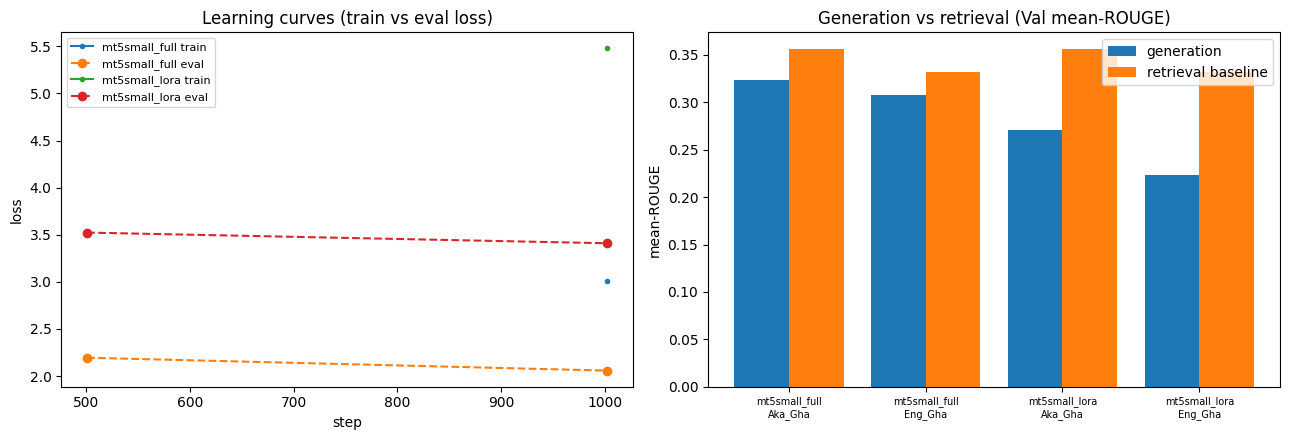

          run  subset    gen  retrieval
mt5small_full Aka_Gha 0.3238      0.356
mt5small_full Eng_Gha 0.3076      0.332
mt5small_lora Aka_Gha 0.2704      0.356
mt5small_lora Eng_Gha 0.2233      0.332


In [ ]:
# 8. Learning curves + generation-vs-retrieval comparison (REQUIRED: training/validation curves)
import os, json, glob
import pandas as pd, matplotlib.pyplot as plt
runs = [d for d in glob.glob('out/*') if os.path.isdir(d) and os.path.exists(f'{d}/history.csv')]
assert runs, 'No runs in out/ — run cell 7 first.'
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5)); rows = []
for d in sorted(runs):
    name = os.path.basename(d); h = pd.read_csv(f'{d}/history.csv')
    tr = h.dropna(subset=['train_loss']) if 'train_loss' in h else pd.DataFrame()
    ev = h.dropna(subset=['eval_loss']) if 'eval_loss' in h else pd.DataFrame()
    if len(tr): ax[0].plot(tr['step'], tr['train_loss'], marker='.', label=f'{name} train')
    if len(ev): ax[0].plot(ev['step'], ev['eval_loss'], marker='o', ls='--', label=f'{name} eval')
    m = json.load(open(f'{d}/metrics.json'))
    for s, v in m['per_subset'].items():
        rows.append({'run': name, 'subset': s, 'gen': v['gen_mean_rouge'], 'retrieval': v['retrieval_baseline']})
ax[0].set(title='Learning curves (train vs eval loss)', xlabel='step', ylabel='loss'); ax[0].legend(fontsize=8)
cmp = pd.DataFrame(rows); piv = cmp.dropna(subset=['gen']).reset_index(drop=True)
if len(piv):
    piv['label'] = piv['run'] + '\n' + piv['subset']; x = range(len(piv)); w = 0.4
    ax[1].bar([i - w/2 for i in x], piv['gen'], w, label='generation')
    ax[1].bar([i + w/2 for i in x], piv['retrieval'], w, label='retrieval baseline')
    ax[1].set_xticks(list(x)); ax[1].set_xticklabels(piv['label'], fontsize=7)
    ax[1].set(title='Generation vs retrieval (Val mean-ROUGE)', ylabel='mean-ROUGE'); ax[1].legend()
plt.tight_layout(); plt.savefig('out/learning_and_comparison.png', dpi=120); plt.show()
print(cmp.to_string(index=False))

In [ ]:
# 9. Bundle outputs and download
import os, glob
from google.colab import files
runs = sorted(glob.glob('out/*/metrics.json'))
assert runs, 'No outputs in out/ — run cell 7.'
print('runs:', [os.path.basename(os.path.dirname(r)) for r in runs])
!cd out && zip -qr ../generator_outputs.zip */val_gen.csv */test_gen.csv */metrics.json */history.csv 2>/dev/null
if os.path.exists('out/learning_and_comparison.png'):
    !zip -qj generator_outputs.zip out/learning_and_comparison.png 2>/dev/null
files.download('generator_outputs.zip')

runs: ['mt5small_full', 'mt5small_lora']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>